In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df_raw = pd.read_csv('/Users/andydascikid/Downloads/Model Predictions.csv')
df_raw = df_raw.iloc[1747:]
df_raw = df_raw[['Date', 'NDCI', 'NDCI_Predicted_ARIMAX', 'NDCI_Predicted_SARIMAX', 'NDCI_Predicted_XGBoost', 'NDCI_Predicted_LSTM']]
df_raw = df_raw.rename(columns={
    'NDCI_Predicted_ARIMAX' : 'ARIMAX',
    'NDCI_Predicted_SARIMAX':'SARIMAX',
    'NDCI_Predicted_XGBoost':'XGBoost',
    'NDCI_Predicted_LSTM':'LSTM'
})

In [3]:
df = df_raw.reset_index(drop=True)


In [4]:
df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=True)
df["Date"] = df["Date"].dt.strftime("%Y-%m-%d")

In [5]:
true_col = 'NDCI'  
pred_cols = ['ARIMAX', 'SARIMAX', 'XGBoost', 'LSTM']

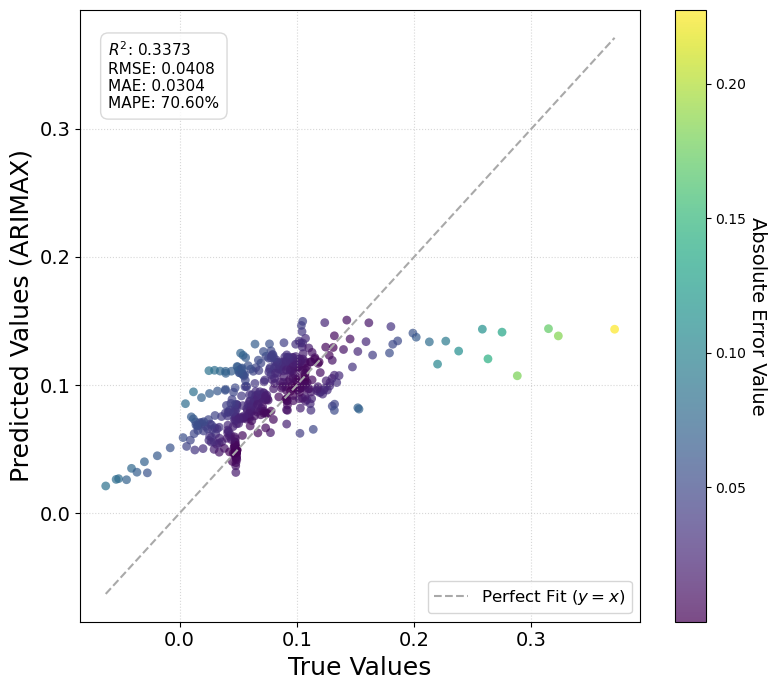

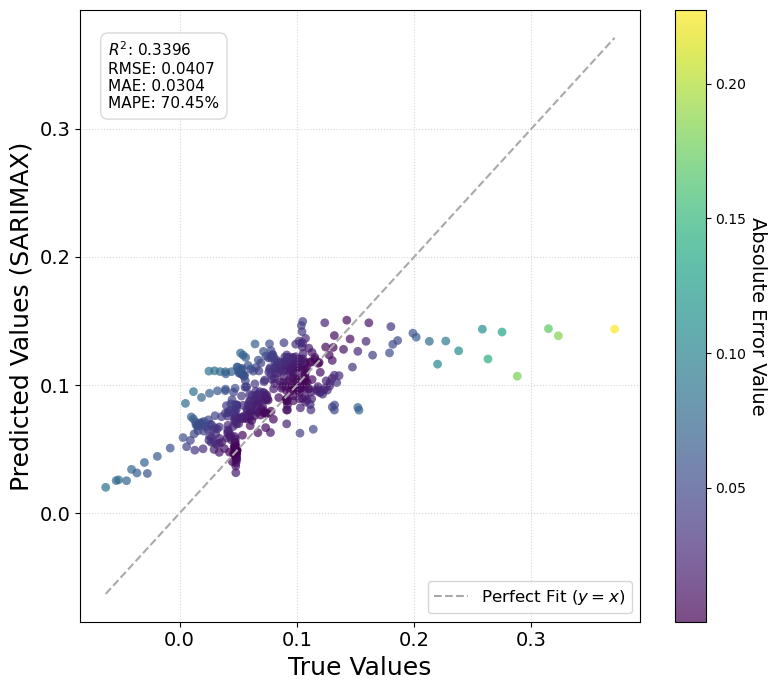

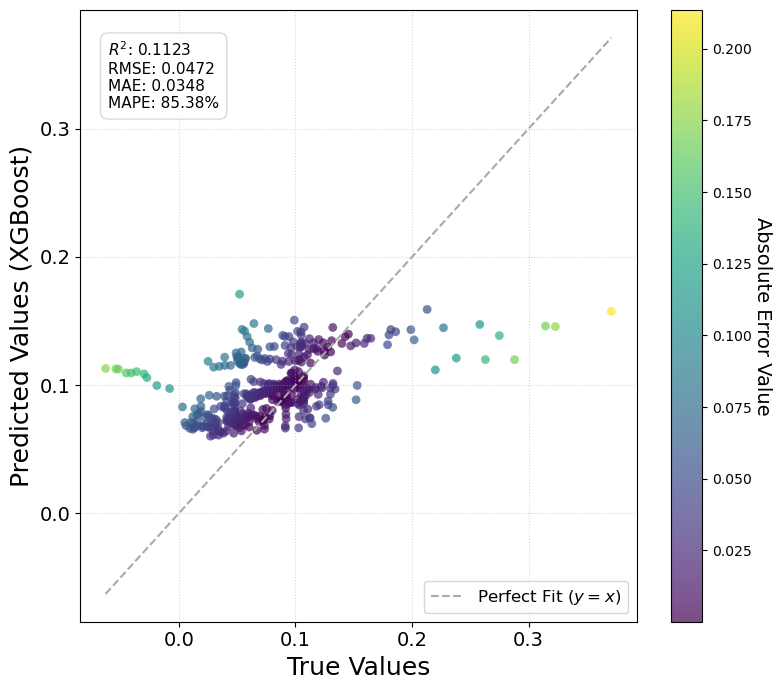

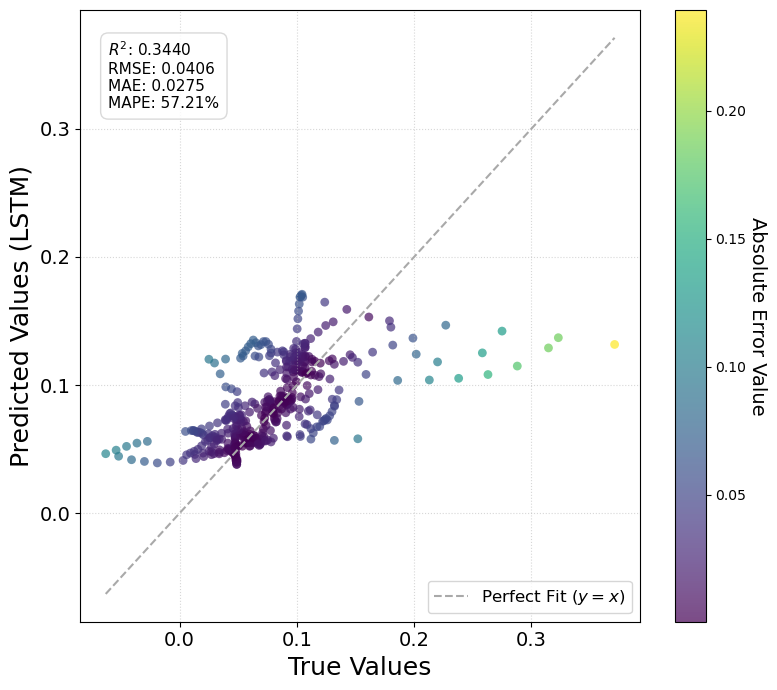

In [6]:
for pred_col in pred_cols:

    clean_data = df[[true_col, pred_col]].dropna()
    y_true = clean_data[true_col].values
    y_pred = clean_data[pred_col].values
    
    abs_error = np.abs(y_true - y_pred)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    slope, intercept = np.polyfit(y_true, y_pred, 1)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    line_coords = np.linspace(min_val, max_val, 100)
    
    fig, ax = plt.subplots(figsize=(8, 7))
    
    sc = ax.scatter(y_true, y_pred, c=abs_error, cmap='viridis', alpha=0.7, edgecolors='none', s=40)
    
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Absolute Error Value', rotation=270, labelpad=15, fontsize = 14)
    
    ax.plot(line_coords, line_coords, color='darkgray', linestyle='--', linewidth=1.5, label='Perfect Fit ($y = x$)')
    
    #ax.plot(line_coords, slope * line_coords + intercept, color='crimson', linestyle='-', linewidth=2, label='Regression Line')
    
    metrics_text = (
        f"$R^2$: {r2:.4f}\n"
        f"RMSE: {rmse:.4f}\n"
        f"MAE: {mae:.4f}\n"
        f"MAPE: {mape:.2f}%"
    )
    
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='lightgray'))
    
    ax.set_xlabel(f"True Values", fontsize=18)
    ax.set_ylabel(f"Predicted Values ({pred_col})", fontsize=18)
    ax.legend(loc='lower right', fontsize = 12)
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)


    fig.tight_layout()
    
    output_filename = f"performance_{pred_col}.pdf"
    fig.savefig(output_filename, dpi=300)
    
    plt.show()

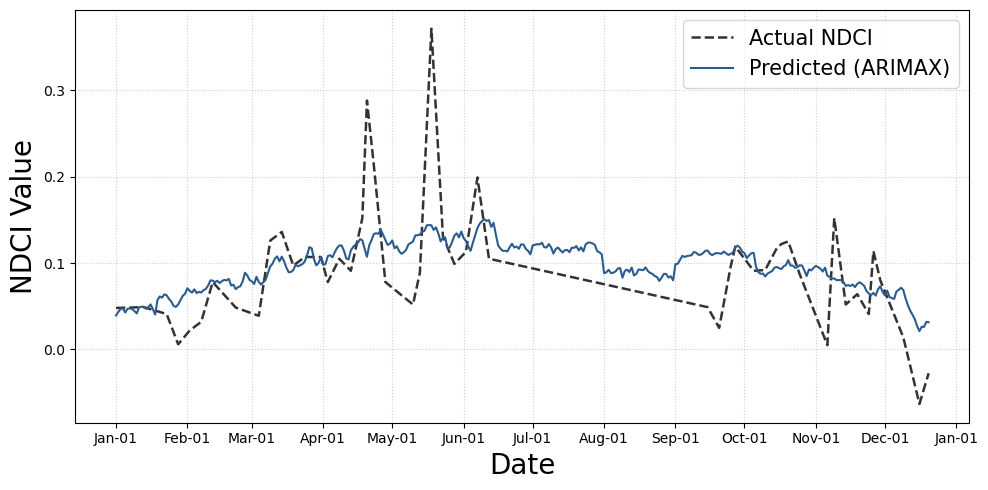

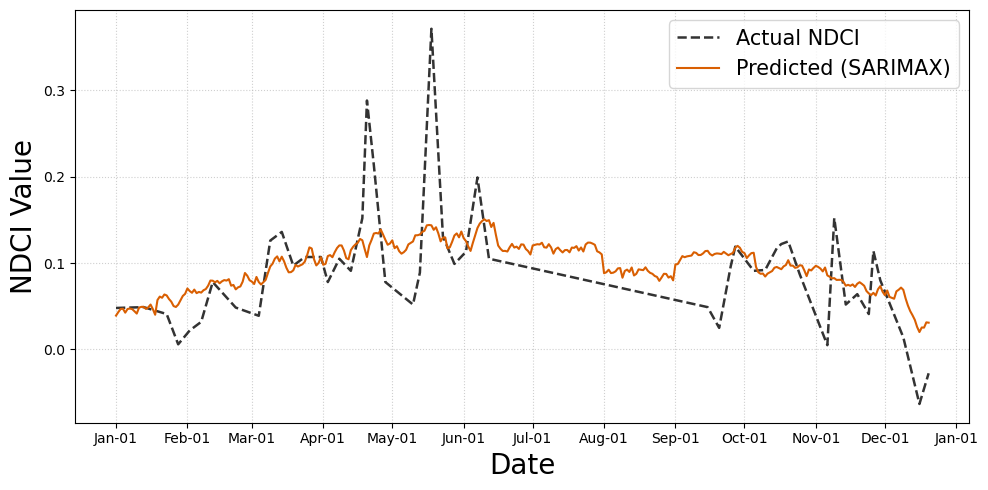

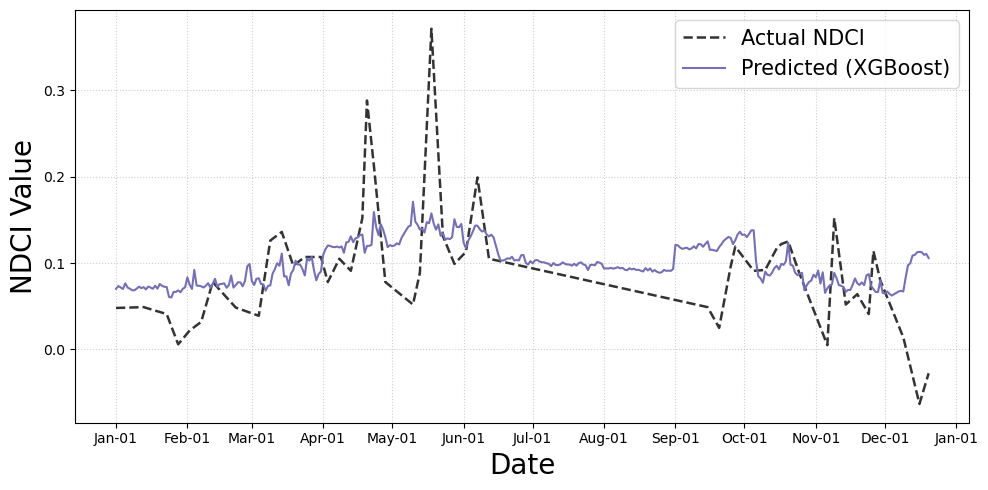

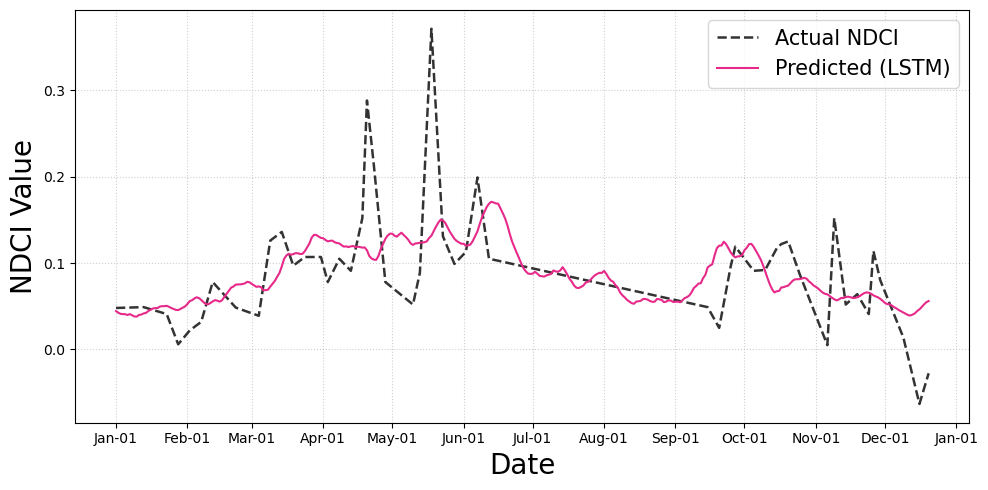

In [39]:
df2 = df[df["Date"].between('2025-01-01', '2025-12-20')]

date_col = "Date"
target_col = "NDCI"
model_cols = ["ARIMAX", "SARIMAX", "XGBoost", "LSTM"]


model_colors = ["#2b5c8f", "#d95f02", "#7570b3", "#e7298a"]

for i, model in enumerate(model_cols):

    plt.figure(figsize=(10, 5))


    plt.plot(
        df2[date_col],
        df2[target_col],
        label="Actual NDCI",
        color="black",
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
    )


    plt.plot(
        df2[date_col],
        df2[model],
        label=f"Predicted ({model})",
        color=model_colors[i],
        linewidth=1.5,
    )


    plt.xlabel("Date", fontsize=20)
    plt.ylabel("NDCI Value", fontsize=20)
    plt.xticks(fontsize=18, rotation=45)
    plt.yticks(fontsize=18)


    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    plt.gca().xaxis.set_major_locator(
        mdates.MonthLocator()
    ) 

    plt.legend(loc="upper right", fontsize = 15, frameon=True)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'{model} Test Data.pdf')


plt.show()

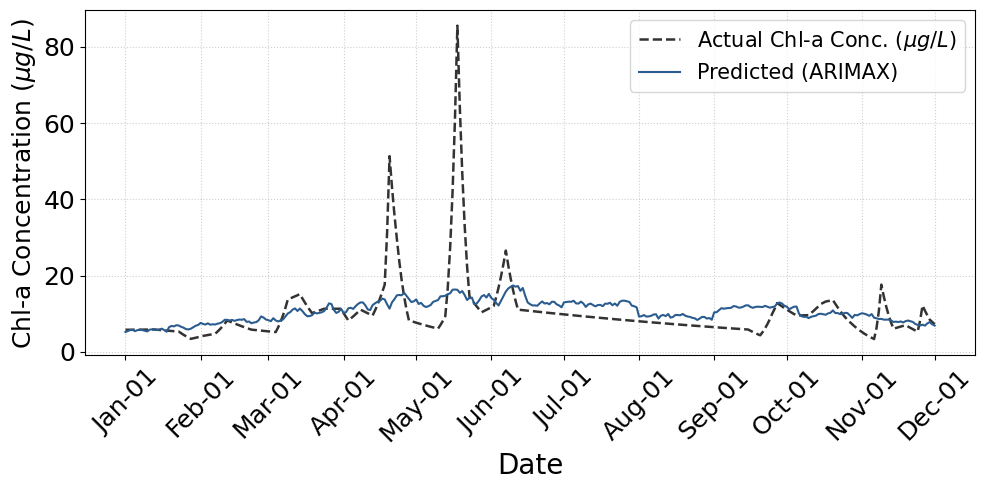

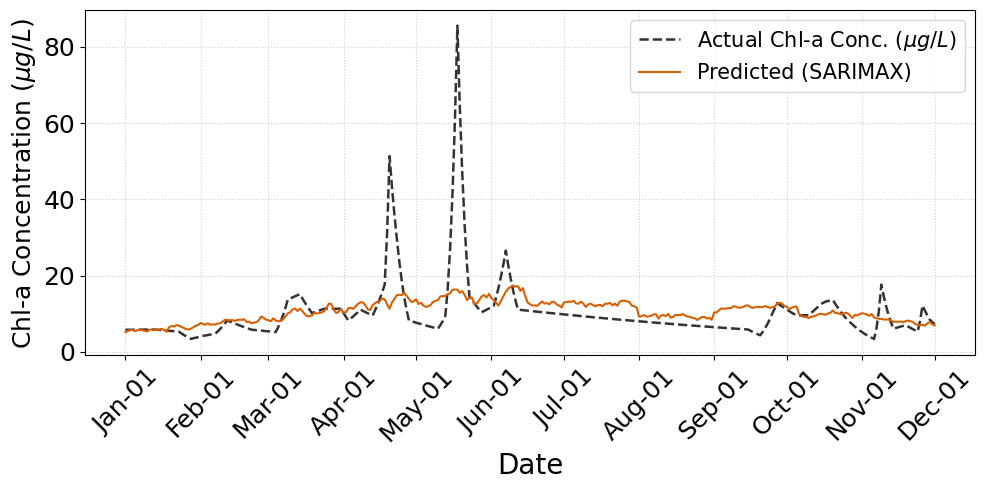

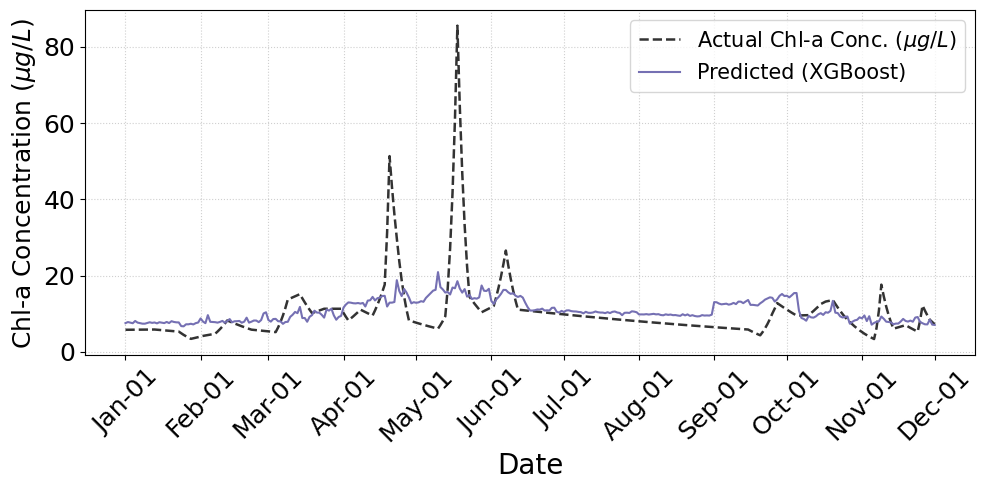

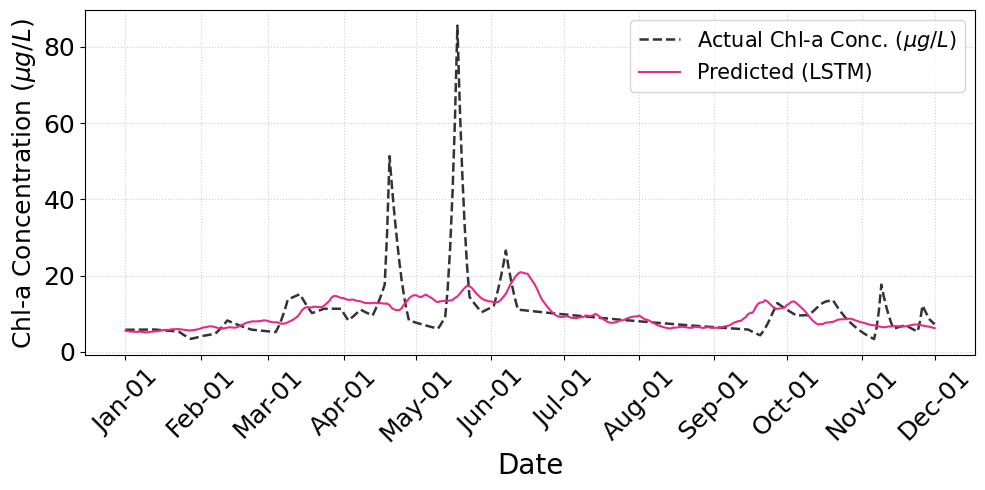

In [7]:
df3 = df[df["Date"].between('2025-01-01', '2025-12-01')]

df3['Chl-a'] = 3.1658 + 40.5537*df3['NDCI'] + 269.7162*((df3['NDCI'])**2) + 592.2277*((df3['NDCI'])**3)
df3['ARIMAX'] = 3.1658 + 40.5537*df3['ARIMAX'] + 269.7162*((df3['ARIMAX'])**2) + 592.2277*((df3['ARIMAX'])**3)
df3['SARIMAX'] = 3.1658 + 40.5537*df3['SARIMAX'] + 269.7162*((df3['SARIMAX'])**2) + 592.2277*((df3['SARIMAX'])**3)
df3['XGBoost'] = 3.1658 + 40.5537*df3['XGBoost'] + 269.7162*((df3['XGBoost'])**2) + 592.2277*((df3['XGBoost'])**3)
df3['LSTM'] = 3.1658 + 40.5537*df3['LSTM'] + 269.7162*((df3['LSTM'])**2) + 592.2277*((df3['LSTM'])**3)

date_col = "Date"
target_col = "Chl-a"
model_cols = ["ARIMAX", "SARIMAX", "XGBoost", "LSTM"]


model_colors = ["#2b5c8f", "#d95f02", "#7570b3", "#e7298a"]

for i, model in enumerate(model_cols):

    plt.figure(figsize=(10, 5))


    plt.plot(
        df3[date_col],
        df3[target_col],
        label= r"Actual Chl-a Conc. ($\mu g/L$)",
        color="black",
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
    )


    plt.plot(
        df3[date_col],
        df3[model],
        label=f"Predicted ({model})",
        color=model_colors[i],
        linewidth=1.5,
    )


    plt.xlabel("Date", fontsize=20)
    plt.ylabel(r"Chl-a Concentration ($\mu g/L$) ", fontsize=18)
    plt.xticks(fontsize=18, rotation=45)
    plt.yticks(fontsize=18)
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    plt.gca().xaxis.set_major_locator(
        mdates.MonthLocator()
    ) 

    plt.legend(loc="upper right", fontsize = 15, frameon=True)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'{model} Test Data.pdf')


plt.show()

In [10]:
df_new = df[['Date', 'NDCI', 'LSTM']]

In [11]:
df_new['Chl-a'] = 3.1658 + 40.5537*df_new['LSTM'] + 269.7162*((df_new['LSTM'])**2) + 592.2277*((df_new['LSTM'])**3)

In [12]:
df_new

,Date,NDCI,LSTM,Chl-a
0,2024-10-13,0.12000,0.117081,12.561600
1,2024-10-14,0.11300,0.118005,12.680400
2,2024-10-15,0.10600,0.117773,12.650471
3,2024-10-16,0.09920,0.115530,12.364175
4,2024-10-17,0.09240,0.114297,12.208824
...,...,...,...,...
429,2025-12-16,-0.06300,0.046421,5.688778
430,2025-12-17,-0.05412,0.049190,5.883745
431,2025-12-18,-0.04525,0.052148,6.098084
432,2025-12-19,-0.03637,0.054688,6.287132


In [13]:
df_new = df_new[df_new["Date"].between('2025-01-01', '2025-12-20')]

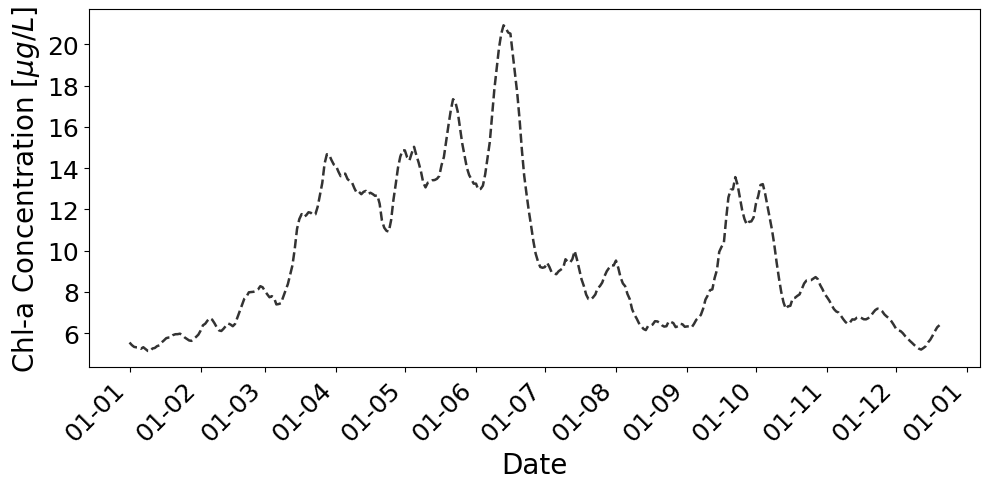

In [14]:
threshold = 15

fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(
        df_new['Date'],
        df_new['Chl-a'],
        color="black",
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
    )


ax.xaxis.set_major_locator(mdates.MonthLocator())

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

fig.autofmt_xdate(rotation=45)


ax.set_xlabel("Date", fontsize=20)
ax.set_ylabel(r"Chl-a Concentration [$\mu g/L$]", fontsize=20)

plt.xticks(fontsize=18, rotation=45)
plt.yticks(fontsize=18)

plt.tight_layout()
plt.savefig('LSTM_HABs_Prediction.pdf')

plt.show()

